In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('digit.csv')

In [3]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
18343,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.shape

(42000, 785)

In [5]:
import matplotlib.pyplot as plt

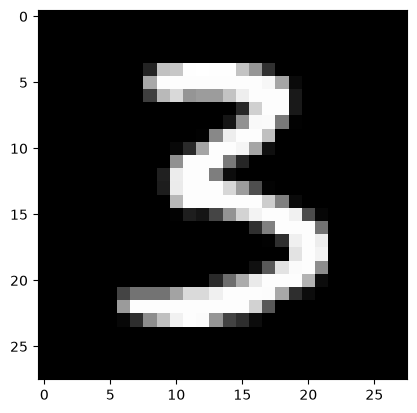

In [6]:
plt.imshow(df.iloc[333, 1:].values.reshape(28, 28), cmap='gray')

In [7]:
X = df.drop('label', axis=1)
y = df['label']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((33600, 784), (8400, 784), (33600,), (8400,))

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [11]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

In [37]:
for i in range(1,785):
    pca = PCA(n_components=i)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    knn = KNeighborsClassifier()
    knn.fit(X_train_pca, y_train)
    y_pred = knn.predict(X_test_pca)
    print(f'Accuracy with {i} components: {knn.score(X_test_pca, y_test)}')


Accuracy with 1 components: 0.2580952380952381
Accuracy with 2 components: 0.3236904761904762
Accuracy with 3 components: 0.5104761904761905
Accuracy with 4 components: 0.6663095238095238
Accuracy with 5 components: 0.7378571428571429
Accuracy with 6 components: 0.8227380952380953
Accuracy with 7 components: 0.8436904761904762
Accuracy with 8 components: 0.8721428571428571
Accuracy with 9 components: 0.886547619047619
Accuracy with 10 components: 0.9055952380952381
Accuracy with 11 components: 0.9116666666666666
Accuracy with 12 components: 0.9184523809523809
Accuracy with 13 components: 0.9276190476190476
Accuracy with 14 components: 0.9351190476190476
Accuracy with 15 components: 0.9384523809523809
Accuracy with 16 components: 0.9379761904761905
Accuracy with 17 components: 0.9407142857142857
Accuracy with 18 components: 0.94
Accuracy with 19 components: 0.9425
Accuracy with 20 components: 0.9442857142857143
Accuracy with 21 components: 0.9438095238095238
Accuracy with 22 components:

KeyboardInterrupt: 

In [13]:
pca2 = PCA(n_components = 2)
X_train_trf2 = pca2.fit_transform(X_train)
X_test_trf2 = pca2.transform(X_test)


In [14]:
X_train_trf2

array([[-2.71863253, -0.48982409],
       [-0.67698015, -6.75362491],
       [-3.03323281,  6.50981624],
       ...,
       [ 2.14883643,  0.78079444],
       [ 1.05957006,  0.94767312],
       [17.70258446,  1.96188185]], shape=(33600, 2))

In [15]:
import plotly.express as px

y_train_trf2 = y_train.astype(str)
fig = px.scatter(x=X_train_trf2[:,0],
                 y=X_train_trf2[:,1],
                 color=y_train_trf2,
                 color_discrete_sequence=px.colors.qualitative.G10)
fig.show()

In [16]:
pca3 = PCA(n_components = 3)
X_train_trf2 = pca3.fit_transform(X_train)
X_test_trf2 = pca3.transform(X_test)


In [17]:
X_train_trf2

array([[-2.71863253, -0.48982409,  1.1354966 ],
       [-0.67698015, -6.75362491, -2.33590139],
       [-3.03323281,  6.50981624,  7.49182983],
       ...,
       [ 2.14883643,  0.78079444, -0.74738774],
       [ 1.05957006,  0.94767312,  3.94973114],
       [17.70258446,  1.96188185, -4.94352837]], shape=(33600, 3))

In [19]:
import plotly.express as px

y_train_trf2 = y_train.astype(str)
fig = px.scatter_3d(x=X_train_trf2[:,0],
                 y=X_train_trf2[:,1],
                 z=X_train_trf2[:,2],
                 color=y_train_trf2,
                 color_discrete_sequence=px.colors.qualitative.G10)
fig.show()

In [20]:
# Eigen values

pca3.explained_variance_

array([40.67111198, 29.17023401, 26.74459621])

In [21]:
# Eigen vectors

pca3.components_

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]], shape=(3, 784))